# DEMO - Testing and Training HerdNet on nadir aerial images

## Setup

For setup instructions see: [Setup Instructions](doc/setup.md)

In [1]:
# Check if GPU is available
!nvidia-smi

Wed Feb  4 12:23:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1080 Ti     Off |   00000000:52:00.0 Off |                  N/A |
|  0%   26C    P8              8W /  280W |       3MiB /  11264MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# pip install wandb --upgrade
!pip install --upgrade --force-reinstall typing_extensions

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0


In [3]:
## If an old GPU like GTX 1080 is available install older torch version which is compatible
# !pip uninstall -y torch torchvision torchaudio
#
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [4]:
!pip install wandb
!pip install ipywidgets
!pip install huggingface-hub

from loguru import logger

logger.disable("animaloc")

# !unzip -oq ./data.zip -d ./

In [5]:
# Download and install the code
import sys

!git clone -b dinov3 https://github.com/cwinkelmann/HerdNet
!cd HerdNet && git pull
!pip install ./HerdNet

sys.path.append('./HerdNet')
sys.path.append('./HerdNet/tools')

fatal: destination path 'HerdNet' already exists and is not an empty directory.
Already up to date.
Processing ./HerdNet
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for animaloc: filename=animaloc-0.3.1-py3-none-any.whl size=239586 sha256=9ea48f06ae6eff018ba240a2a71cbe61bca8448997d2397cac51b14235e8d47b
  Stored in directory: /tmp/pip-ephem-wheel-cache-2t3e73fn/wheels/94/37/b6/e36a5be49761e6deb8e2a29c8ddd5d4ac17d99ed07bb70e425
Successfully built animaloc
  Attempting uninstall: animaloc
    Found existing installation: animaloc 0.3.1
    Uninstalling animaloc-0.3.1:
      Successfully uninstalled animaloc-0.3.1


## Download Models and Demo Datasets

Data and Models are hosted on Huggingface, see:

https://huggingface.co/karisu/HerdNet
and
https://huggingface.co/datasets/karisu/General_Dataset 

In [35]:
from huggingface_hub import hf_hub_download
from pathlib import Path
local_dir = Path("./models").resolve()

# Download specific files
model_path = hf_hub_download(
    repo_id="karisu/HerdNet",
    filename="general_2022/20220413_HerdNet_General_dataset_2022.pth",  # adjust filename as needed
    local_dir=local_dir
)

config_path = hf_hub_download(
    repo_id="karisu/HerdNet",
    filename="general_2022/config.yaml",
    local_dir=local_dir
)

print(f"Model Path: {model_path} and Config Path: {config_path}")

general_2022/20220413_HerdNet_General_da(…):   0%|          | 0.00/220M [00:00<?, ?B/s]

Model Path: /home/christian/hnee/HerdNet/notebooks/models/general_2022/20220413_HerdNet_General_dataset_2022.pth and Config Path: /home/christian/hnee/HerdNet/notebooks/models/general_2022/config.yaml


In [7]:
data_path = hf_hub_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    filename="general_dataset.zip",  # specify the file path within the repo
    local_dir="./data",
)
data_path

general_dataset.zip:   0%|          | 0.00/11.9G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

Load a seperate Sample of the test set

In [20]:
from huggingface_hub import snapshot_download

# load a small sample of the testset
sample_data_path = snapshot_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    local_dir="./data",
    allow_patterns=["test_sample/*"],  # multiple folders
    revision="main",                        # branch/tag/commit
)
sample_data_path

test_sample_annotation_path = hf_hub_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    filename="test_sample.csv",  # specify the file path within the repo
    local_dir="./data",
)

Fetching ... files: 0it [00:00, ?it/s]

test_sample.csv: 0.00B [00:00, ?B/s]

In [ ]:
# Install unzip on a linux system, unzip manually otherwise 
!apt-get update && apt-get install -y unzip



In [ ]:
!unzip -oq ./data/general_dataset.zip -d ./data

### Create the Helper Functions


In [21]:
# Test installation
# Set the seed
from animaloc.utils.seed import set_seed

set_seed(9292)

In [22]:
# Training, validation and test datasets
import albumentations as A

from animaloc.datasets import CSVDataset
from animaloc.data.transforms import MultiTransformsWrapper, DownSample, PointsToMask, FIDT

patch_size = 512
num_classes = 7
down_ratio = 2



test_dataset = CSVDataset(
    csv_file = './data/test_sample.csv',
    root_dir = './data/test_sample',
    albu_transforms = [A.Normalize(p=1.0)],
    end_transforms = [DownSample(down_ratio=down_ratio, anno_type='point')]
    )

In [23]:
# Dataloaders
from torch.utils.data import DataLoader



test_dataloader = DataLoader(dataset = test_dataset, batch_size = 1, shuffle = False)

The Loss Wrapper is needed to evaluate the model against a known test-set

In [24]:
from animaloc.models import HerdNet
from torch import Tensor
from animaloc.models import LossWrapper
from animaloc.train.losses import FocalLoss
from torch.nn import CrossEntropyLoss

herdnet = HerdNet(num_classes=num_classes, down_ratio=down_ratio).cuda()

weight = Tensor([0.1, 1.0, 2.0, 1.0, 6.0, 12.0, 1.0]).cuda()

losses = [
    {'loss': FocalLoss(reduction='mean'), 'idx': 0, 'idy': 0, 'lambda': 1.0, 'name': 'focal_loss'},
    {'loss': CrossEntropyLoss(reduction='mean', weight=weight), 'idx': 1, 'idy': 1, 'lambda': 1.0, 'name': 'ce_loss'}
    ]

## This loss Wrapper is important for the Evaluator
herdnet = LossWrapper(herdnet, losses=losses)

The Stitched allows for inference on images larger than 512px

In [25]:
from torch.optim import Adam
from animaloc.train import Trainer
from animaloc.eval import PointsMetrics, HerdNetStitcher, HerdNetEvaluator
from animaloc.utils.useful_funcs import mkdir

work_dir = './output'
mkdir(work_dir)

lr = 1e-4
weight_decay = 1e-3
epochs = 5

optimizer = Adam(params=herdnet.parameters(), lr=lr, weight_decay=weight_decay)

metrics = PointsMetrics(radius=20, num_classes=num_classes)

stitcher = HerdNetStitcher(
    model=herdnet,
    size=(patch_size,patch_size),
    overlap=160,
    down_ratio=down_ratio,
    reduction='mean'
    )





## Running HerdNet

At first a pretrained model is run against the Test Subset on African Megafauna.
Then it shown how to train the model.


### Test the pretrained model

A download model is run against

In [26]:

# Load trained parameters
from animaloc.models import load_model
pth_path = './models/general_2022/20220413_HerdNet_General_dataset_2022.pth'

herdnet = load_model(herdnet, pth_path=pth_path)
herdnet = LossWrapper(herdnet, losses=losses)

In [27]:
# Create output folder
test_dir = './test_output'
mkdir(test_dir)

In [28]:
# Create an Evaluator
test_evaluator = HerdNetEvaluator(
    model=herdnet,
    dataloader=test_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=test_dir,
    header='test'
    )

In [29]:
# Start testing
test_f1_score = test_evaluator.evaluate(returns='f1_score')

test [1/7] eta: 0:00:24 n: 11 tp: 1 fp: 2 fn: 8 recall: 0.11 precision: 0.33 f1_score: 0.17 f2_score: 0.13 f5_score: 0.11 MAE: 6.0 ME: 0.0 MSE: 36.0 RMSE: 6.0 avg_score: 0.01 avg_dscore: 0.084 time: 3.5567 data: 0.6086 max mem: 1339
test [7/7] eta: 0:00:03 n: 13 tp: 7 fp: 1 fn: 5 recall: 0.58 precision: 0.88 f1_score: 0.7 f2_score: 0.63 f5_score: 0.59 MAE: 4.0 ME: 0.0 MSE: 16.0 RMSE: 4.0 avg_score: 0.83 avg_dscore: 0.22 time: 3.1691 data: 0.5137 max mem: 1492
test Total time: 0:00:22 (3.1695 s / it)


In [30]:
# Print global F1 score (%)
print(f"F1 score = {test_f1_score * 100:0.0f}%")
# New implementation training 38%
# loaded model 83%

F1 score = 62%


In [31]:
# Get the detections
detections = test_evaluator.results
detections

,class,n,recall,precision,f1_score,confusion,mae,me,mse,rmse,ap
0,1,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
1,2,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
2,3,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
3,4,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
4,5,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
5,6,41,0.560976,0.69697,0.621622,0.0,2.285714,-1.142857,8.571429,2.9277,0.530441
6,binary,41,0.560976,0.69697,0.621622,0.0,2.285714,0.000000,8.571429,2.9277,0.530441


## Inferencing using a config file
Here just the model and configuration is loaded making the process transferable. Any config can be overridden.

In [48]:

from pathlib import Path
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

# Clear any previous Hydra state (important in notebooks when re-running cells)
GlobalHydra.instance().clear()

# Configure paths
config_dir = str(Path.cwd() / "models/general_2022")  # adjust as needed
config_name = "config"

# Load config
with initialize_config_dir(config_dir=config_dir, version_base="1.1"):
    cfg = compose(config_name=config_name, overrides=[
        # Add any overrides here, e.g.:
        # "training.epochs=10",
        #  "training.batch_size=4",
        "model.load_from=./models/general_2022/20220413_HerdNet_General_dataset_2022.pth",
        "datasets.test.root_dir=./data/test_sample/"
    ])

# Inspect config (optional) It contains all which was used for training
print(OmegaConf.to_yaml(cfg))

losses:
  FocalLoss:
    print_name: focal_loss
    from_torch: false
    output_idx: 0
    target_idx: 0
    lambda_const: 1.0
    kwargs:
      alpha: 2
      beta: 4
      reduction: mean
      normalize: false
  CrossEntropyLoss:
    print_name: ce_loss
    from_torch: true
    output_idx: 1
    target_idx: 1
    lambda_const: 1.0
    background_class_weight: 0.1
    kwargs:
      reduction: mean
      weight:
      - ${losses.CrossEntropyLoss.background_class_weight}
      - 1.0
      - 2.0
      - 1.0
      - 6.0
      - 12.0
      - 1.0
datasets:
  img_size:
  - 512
  - 512
  anno_type: point
  num_classes: 7
  collate_fn: null
  class_def:
    1: Alcelaphinae
    2: Buffalo
    3: Kob
    4: Warthog
    5: Waterbuck
    6: Elephant
  train:
    name: CSVDataset
    csv_file: /raid/cwinkelmann/training_data/iguana/2025_12_02/last_run/train/herdnet_format_800_160_crops.csv
    root_dir: /raid/cwinkelmann/training_data/iguana/2025_12_02/last_run/train/crops_800_numNone_overlap160


In [49]:
from animaloc.utils.inference import inference

# Run inference
detections = inference(cfg, plain_inference=True, vis_detections=True)



[TEST] [1/7] eta: 0:00:21 n: 5 tp: 0 fp: 4 fn: 1 recall: 0.0 precision: 0.0 f1_score: 0.0 f2_score: 0.0 f5_score: 0.0 MAE: 3.0 ME: -1.0 MSE: 9.0 RMSE: 3.0 avg_score: 0.41 avg_dscore: 0.137 time: 3.0345 data: 0.6443 max mem: 1492
[TEST] [7/7] eta: 0:00:02 n: 7 tp: 0 fp: 6 fn: 1 recall: 0.0 precision: 0.0 f1_score: 0.0 f2_score: 0.0 f5_score: 0.0 MAE: 5.0 ME: -7.0 MSE: 25.0 RMSE: 5.0 avg_score: 0.47 avg_dscore: 0.119 time: 2.9520 data: 0.5099 max mem: 1492
[TEST] Total time: 0:00:20 (2.9523 s / it)


/home/christian/anaconda3/envs/HerdNet/lib/python3.11/site-packages/animaloc/eval/metrics.py:338: RuntimeWarning: invalid value encountered in divide
  recalls = sorted_table[:,2] / n_gt


In [50]:
# Show results
print(f"Total detections: {len(detections)}")
detections.head(10)

Total detections: 39


,images,labels,scores,dscores,x,y,count_1,count_2,count_3,count_4,count_5,count_6,species
0,02033bf9b6c41f5815072434f8d61707cc8ea1fb.jpeg,6.0,0.999953,0.305873,5260.0,1552.0,0,0,0,0,0,4,Elephant
1,02033bf9b6c41f5815072434f8d61707cc8ea1fb.jpeg,6.0,0.396535,0.106754,236.0,1580.0,0,0,0,0,0,4,Elephant
2,02033bf9b6c41f5815072434f8d61707cc8ea1fb.jpeg,6.0,0.072899,0.062465,822.0,3308.0,0,0,0,0,0,4,Elephant
3,02033bf9b6c41f5815072434f8d61707cc8ea1fb.jpeg,6.0,0.152507,0.071073,758.0,3636.0,0,0,0,0,0,4,Elephant
4,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.143989,0.109976,96.0,2554.0,0,0,0,0,0,11,Elephant
5,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.978223,0.345213,336.0,2622.0,0,0,0,0,0,11,Elephant
6,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.462835,0.105038,92.0,2658.0,0,0,0,0,0,11,Elephant
7,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.970488,0.262854,508.0,2670.0,0,0,0,0,0,11,Elephant
8,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.874156,0.220338,614.0,3032.0,0,0,0,0,0,11,Elephant
9,04e8092d743bef891386f3e0ce82155f12aa4035.jpeg,6.0,0.991656,0.335539,776.0,3120.0,0,0,0,0,0,11,Elephant


### TODO: Visualise detections

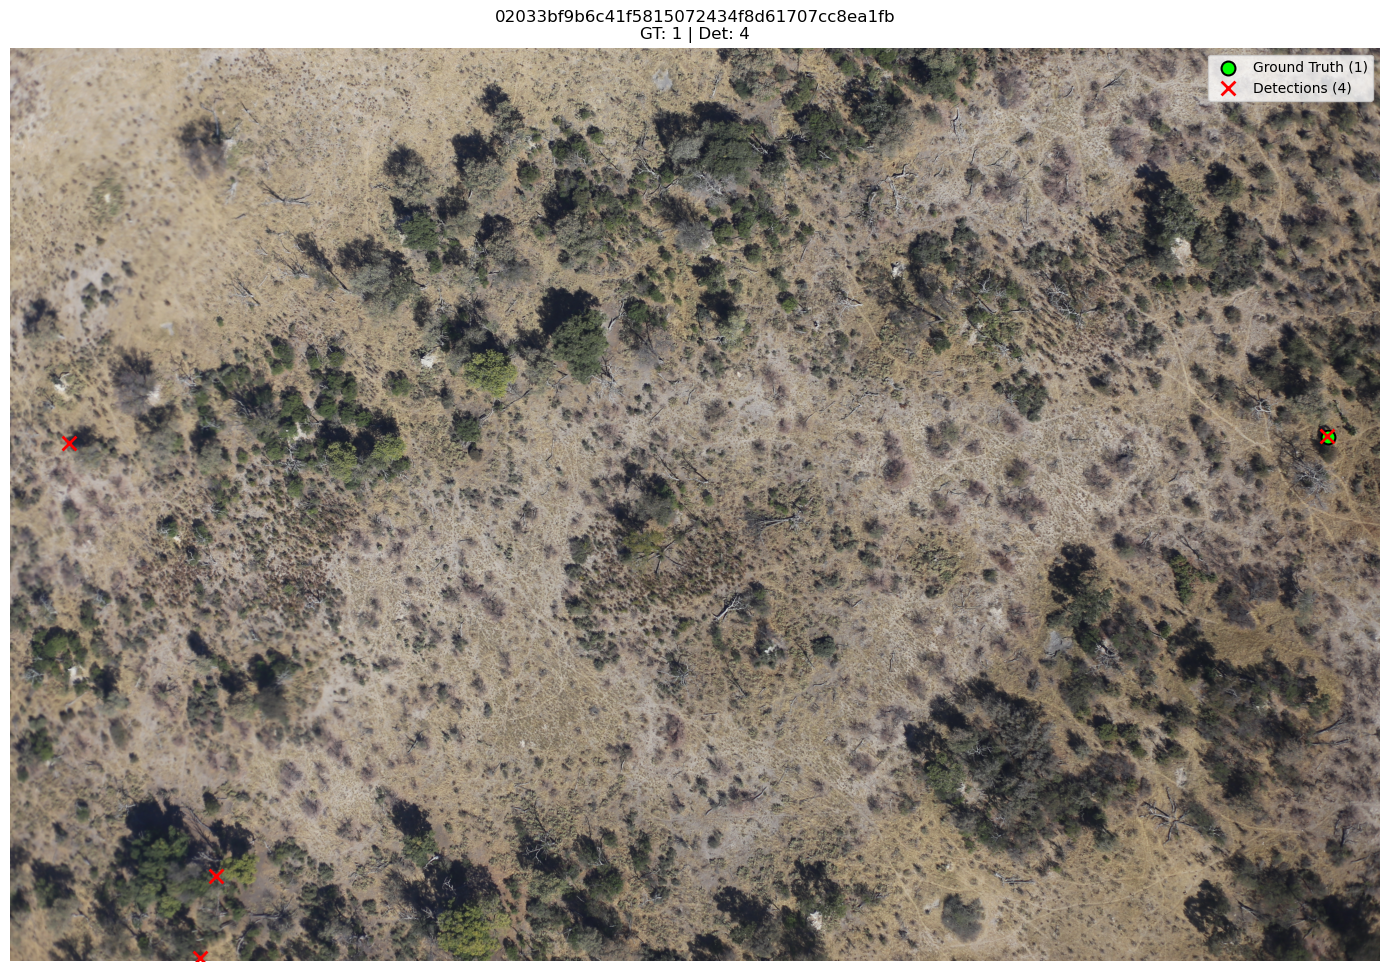

In [56]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load data
gt_df = pd.read_csv("data/test_sample.csv")
det_df = pd.read_csv("detections.csv")

# First image
image_stem = "02033bf9b6c41f5815072434f8d61707cc8ea1fb"
image_path = f"data/test_sample/{image_stem}.jpeg"

# Get ground truth annotations (handle .JPG extension in CSV)
gt = gt_df[gt_df["images"].str.startswith(image_stem)]

# Get detections
det = det_df[det_df["images"] == f"{image_stem}.jpeg"].dropna(subset=["x", "y"])

# Plot
img = Image.open(image_path)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)

# Ground truth in green
ax.scatter(gt["x"], gt["y"], c="lime", s=100, marker="o", 
           edgecolors="black", linewidths=1.5, label=f"Ground Truth ({len(gt)})")

# Detections in red
ax.scatter(det["x"], det["y"], c="red", s=100, marker="x", 
           linewidths=2, label=f"Detections ({len(det)})")

ax.set_title(f"{image_stem}\nGT: {len(gt)} | Det: {len(det)}")
ax.legend(loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.savefig("detection_plot.png", dpi=150, bbox_inches="tight")


Found 4 thumbnails


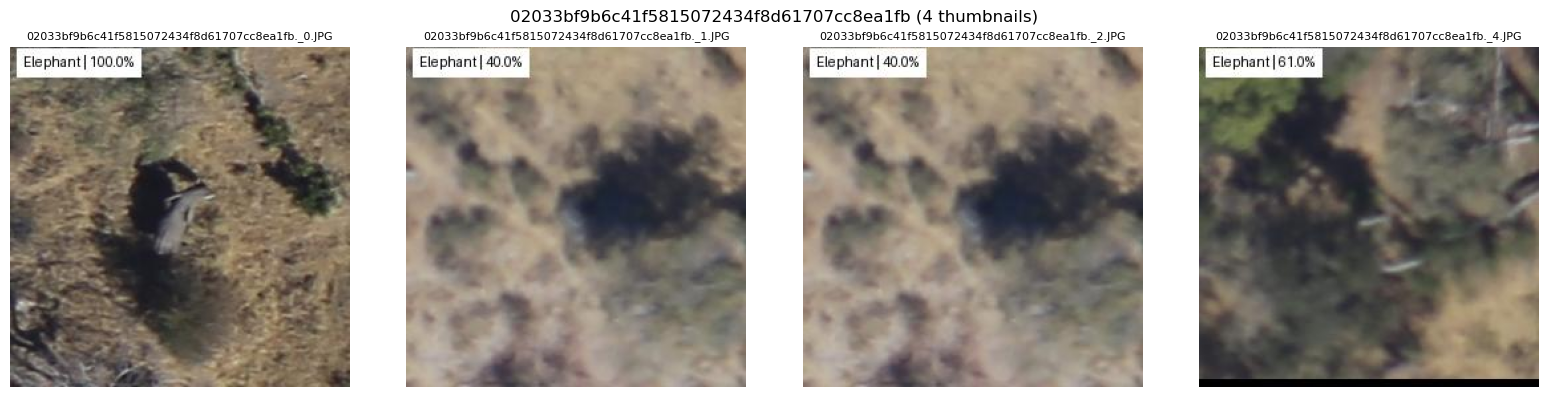

In [57]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Image stem to plot
thumbnails_folder = Path("thumbnails")

# Find all thumbnails for this stem
thumbnails = sorted(thumbnails_folder.glob(f"{image_stem}._*.JPG"))

print(f"Found {len(thumbnails)} thumbnails")

# Plot all in a grid
n_cols = 4
n_rows = (len(thumbnails) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten() if len(thumbnails) > 1 else [axes]

for ax, thumb_path in zip(axes, thumbnails):
    img = Image.open(thumb_path)
    ax.imshow(img)
    ax.set_title(thumb_path.name, fontsize=8)
    ax.axis("off")

# Hide empty subplots
for ax in axes[len(thumbnails):]:
    ax.axis("off")

plt.suptitle(f"{image_stem} ({len(thumbnails)} thumbnails)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{image_stem}_thumbnails.png", dpi=150, bbox_inches="tight")

## Actuall Training

In [ ]:
from animaloc.utils.train import main


### Manual Patch creation
Patch larger images into trainable tiles

In [ ]:
# Create validation patches using the patcher tool (for demo)
from animaloc.utils.useful_funcs import mkdir

mkdir('./data/val_patches')
!python ./HerdNet/tools/patcher.py ./data/val 512 512 0 ./data/val_patches -csv ./data/val.csv -min 0.0 -all False

In [ ]:
train_dataset = CSVDataset(
    csv_file = './data/train_patches.csv',
    root_dir = './data/train_patches',
    albu_transforms = [
        A.VerticalFlip(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.2),
        A.Blur(blur_limit=15, p=0.2),
        A.Normalize(p=1.0)
        ],
    end_transforms = [MultiTransformsWrapper([
        FIDT(num_classes=num_classes, down_ratio=down_ratio),
        PointsToMask(radius=2, num_classes=num_classes, squeeze=True, down_ratio=int(patch_size//16))
        ])]
    )

val_dataset = CSVDataset(
    csv_file = './data/val_patches/gt.csv',
    root_dir = './data/val_patches',
    albu_transforms = [A.Normalize(p=1.0)],
    end_transforms = [DownSample(down_ratio=down_ratio, anno_type='point')]
    )

In [ ]:
train_dataloader = DataLoader(dataset = train_dataset, batch_size = 12, shuffle = True)

val_dataloader = DataLoader(dataset = val_dataset, batch_size = 1, shuffle = False)

In [ ]:
evaluator = HerdNetEvaluator(
    model=herdnet,
    dataloader=val_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=work_dir,
    header='validation'
    )

In [ ]:
trainer = Trainer(
    model=herdnet,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    num_epochs=epochs,
    evaluator=evaluator,
    work_dir=work_dir
    )

In [ ]:
trainer.start(warmup_iters=100, checkpoints='best', select='max', validate_on='f1_score')


### Evaluate the just trained model

In [ ]:
# Create an Evaluator
test_evaluator = HerdNetEvaluator(
    model=herdnet_general,
    dataloader=test_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=test_dir,
    header='test'
    )